In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [17]:
df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")
df.head()

C:\Users\mdmah\AppData\Local\Temp\ipykernel_36136\416291458.py:1: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta")


,caseid_new,w3_Weight,w3_Weight_LGB,w3_combo_weight,w3_attrition_adj_weight,w2_weight_genpop,w2_weight_LGB,w2_combo_weight,w2_attrition_adj_weights,w1_weight_combo,...,p20_pppa1634,p20_pppa1902,p20_pppa1903,p20_pppa1904,p20_ppp22001,p20_pppa1905,p20_pppa1648,p20_ppp20072,p20_ppp20071,p20_ppp2date2020
0,53001,0.4422,NaN,0.495308,0.400185,0.3856,NaN,0.437670,0.380351,0.426861,...,Female,No,Female,No,No,No,No religion,Never,NaN,20210506.0
1,71609,0.8284,NaN,0.927891,0.879258,0.9196,NaN,1.043778,0.953948,1.295508,...,Female,No,Female,No,No,No,"Evangelical or Protestant Christian (Baptist, ...",Once a year or less,Yes,20201118.0
2,106983,0.8255,NaN,0.924643,0.706467,0.7748,NaN,0.879425,0.724682,1.126573,...,Male,Male,No,No,No,No,Catholic,A few times a year,No,20210429.0
3,121759,NaN,NaN,NaN,NaN,0.9177,NaN,1.041622,0.793093,0.933440,...,Male,Male,No,No,No,No,Other Christian religion,Once a week,Yes,20210507.0
4,158083,0.8810,NaN,0.986809,0.655467,0.8697,NaN,0.987140,0.735473,0.931291,...,Male,Male,No,No,No,No,No religion,Never,NaN,20210602.0


In [18]:
print(df.shape)
print(df.columns.tolist()[:100])

(3510, 725)
['caseid_new', 'w3_Weight', 'w3_Weight_LGB', 'w3_combo_weight', 'w3_attrition_adj_weight', 'w2_weight_genpop', 'w2_weight_LGB', 'w2_combo_weight', 'w2_attrition_adj_weights', 'w1_weight_combo', 'w1_weight_combo_freqwt', 'w3_xpartner_type', 'w3_xlast_contact_year', 'w3_xcohab', 'w3_xsamesex', 'w3_xlast_contact_mo', 'w3_xnamep_present', 'w3_duration', 'w3_gen_pop_sample', 'w3_ppage', 'w3_ppagecat', 'w3_ppagect4', 'w3_ppeduc', 'w3_ppeducat', 'w3_ppethm', 'w3_ppgender', 'w3_pphhhead', 'w3_pphhsize', 'w3_pphouse', 'w3_ppincimp', 'w3_real_inc', 'w3_log_real_inc', 'w3_ppmarit', 'w3_ppmsacat', 'w3_PPREG4', 'w3_ppreg9', 'w3_pprent', 'w3_PPT01', 'w3_PPT25', 'w3_PPT612', 'w3_total_kids_lt13', 'w3_PPT1317', 'w3_PPT18OV', 'w3_ppwork', 'w3_surveyed', 'w3_section', 'w3_partner_type', 'w3_married', 'w3_otherdate', 'w3_coronavirus_effect_combo', 'w3_corona_effect_combo_reversed', 'w3_live_w_partner', 'w3_same_sex_couple', 'w3_marriage_dp', 'w3_mar_dp_why_words', 'w3_mar_dp_why_len', 'w3_mar

In [19]:
cluster_cols = [
    # Relationship structure
    "w3_partner_type",
    "w3_married",
    "w3_live_w_partner",
    "w3_same_sex_couple",

    # Relationship dynamics
    "w3_rel_qual",
    "w3_sex_frequency",
    "w3_p_monogamy",

    # Duration / commitment
    "w3_duration",

    # Demographics
    "w3_ppage",
    "w3_ppgender",
    "w3_ppeducat",
    "w3_ppmarit",

    # Context
    "w3_coronavirus_effect_combo",

    # Children / household
    "w3_total_kids_lt13"
]

In [20]:
df_cluster = df[cluster_cols].copy()

print(df_cluster.shape)
df_cluster.head()

(3510, 14)


,w3_partner_type,w3_married,w3_live_w_partner,w3_same_sex_couple,w3_rel_qual,w3_sex_frequency,w3_p_monogamy,w3_duration,w3_ppage,w3_ppgender,w3_ppeducat,w3_ppmarit,w3_coronavirus_effect_combo,w3_total_kids_lt13
0,in unmarried partnership,no,yes,no,Excellent,Once or twice a week,"yes, I expect partner will only have sex with me",5.88,53.0,Female,High school,Divorced,Our relationship is better than before,0.0
1,married,yes,yes,no,Good,Once a month or less,"yes, I expect partner will only have sex with me",10.47,72.0,Female,Some college,Married,No change,0.0
2,married,yes,yes,no,Excellent,Once or twice a week,"yes, I expect partner will only have sex with me",4.43,43.0,Male,Some college,Married,No change,0.0
3,not in wave 3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,unpartnered,no,NaN,NaN,NaN,NaN,NaN,5.34,53.0,Male,Some college,Divorced,NaN,0.0


In [21]:
df_cluster = df_cluster.dropna(subset=["w3_rel_qual"])
df_cluster.isna().mean().sort_values(ascending=False)
df_cluster.shape

(1337, 14)

In [22]:
cat_cols = df_cluster.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = df_cluster.select_dtypes(include=["number"]).columns.tolist()
cat_cols.remove("w3_rel_qual")
print("Categorical:", cat_cols)
print("Numeric:", num_cols)

Categorical: ['w3_partner_type', 'w3_married', 'w3_live_w_partner', 'w3_same_sex_couple', 'w3_sex_frequency', 'w3_p_monogamy', 'w3_ppgender', 'w3_ppeducat', 'w3_ppmarit', 'w3_coronavirus_effect_combo']
Numeric: ['w3_duration', 'w3_ppage', 'w3_total_kids_lt13']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

X_cluster = preprocessor.fit_transform(df_cluster)

print(X_cluster.shape)

(1337, 34)


In [24]:
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    print(f"k={k}, score={score:.4f}")

c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


k=2, score=0.2436
k=3, score=0.2421
k=4, score=0.2934
k=5, score=0.1660


c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(
c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


k=6, score=0.1544


In [25]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster["cluster"] = kmeans.fit_predict(X_cluster)

df_cluster["cluster"].value_counts()

c:\Users\mdmah\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=6.
  warnings.warn(


cluster
1    888
0    265
2    178
3      6
Name: count, dtype: int64

In [26]:
cluster_counts = df_cluster["cluster"].value_counts()
valid_clusters = cluster_counts[cluster_counts > 50].index

df_cluster = df_cluster[df_cluster["cluster"].isin(valid_clusters)].copy()

X_cluster = preprocessor.fit_transform(df_cluster)

print(df_cluster.shape)
print(X_cluster.shape)

(1331, 15)
(1331, 34)


In [27]:
df_cluster["cluster"].value_counts()

cluster
1    888
0    265
2    178
Name: count, dtype: int64

In [28]:
pd.crosstab(df_cluster["cluster"], df_cluster["w3_married"], normalize="index")

w3_married,no,yes
cluster,,
0,0.992453,0.007547
1,0.000000,1.000000
2,0.067416,0.932584


In [29]:
pd.crosstab(df_cluster["cluster"], df_cluster["w3_live_w_partner"], normalize="index")

w3_live_w_partner,no,yes
cluster,,
0,0.425856,0.574144
1,0.018018,0.981982
2,0.016854,0.983146


In [30]:
df_cluster.groupby("cluster")[num_cols].mean()

,w3_duration,w3_ppage,w3_total_kids_lt13
cluster,,,
0,15.453774,48.437736,0.067925
1,11.484200,61.313063,0.022523
2,10.862584,39.376404,1.955056


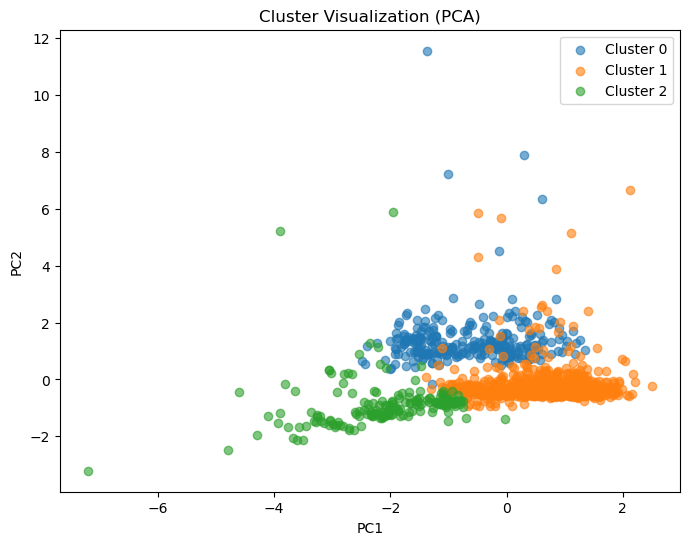

In [31]:
X_dense = X_cluster.toarray() if hasattr(X_cluster, "toarray") else X_cluster

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

clusters = df_cluster["cluster"].astype(int)
unique_clusters = np.unique(clusters)

plt.figure(figsize=(8, 6))

for cluster in unique_clusters:
    mask = clusters == cluster
    
    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=f"Cluster {cluster}",
        alpha=0.6
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Visualization (PCA)")
plt.legend()
plt.show()